In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from PF2nlfff.packages import *
from PF2nlfff.model_3D import *
from PF2nlfff.tools import *
from PF2nlfff.mf_module import *

In [ ]:
start_idx = 0
end_idx = 20

product_info_path = './archive-202203-info.csv'
product_info = pandas.read_csv(product_info_path)

path = '../nlfff/*'
dirs_list = glob.glob(path)

data_set_list = []

for i in range(len(dirs_list)):
    file_list = get_files_with_path(dirs_list[i])
    sample_harpnum_trec_list = []
    for i in range(len(file_list)):
        match = re.search(r'\d+\.\d{8}_\d{6}_\w+', file_list[i])
        if match:
            extracted_part = match.group()
            sample_harpnum_trec = extracted_part
            sample_harpnum_trec_list.append(sample_harpnum_trec)

    sample_product_info = product_info[product_info['harpnum_trec'].isin(sample_harpnum_trec_list)]
    min_grid_xyz = min(sample_product_info["grid_xyz"])
    filtered_data = sample_product_info[sample_product_info['grid_xyz'] == min_grid_xyz]
    file_name_list = pd.DataFrame({'file_name':file_list})
    filtered_harpnum_trec_list = filtered_data["harpnum_trec"].tolist()
    filtered_file_name_list = file_name_list[file_name_list["file_name"].str.contains('|'.join(filtered_harpnum_trec_list))]
    data_set_list.append(filtered_file_name_list["file_name"].tolist())
    
file_size_list = []
for i in range(len(data_set_list)):
    file_size = os.path.getsize(data_set_list[i][0])
    file_size_list.append(file_size)
    
sorted_index_list = sorted(range(len(data_set_list)), key=lambda x: file_size_list[x], reverse=True)
data_set_sorted_by_size = [data_set_list[i] for i in sorted_index_list]
min_file_nums = 10000
file_num_list = []
idx = 0
for i in range(len(data_set_sorted_by_size[10:])):
    if len(data_set_sorted_by_size[10:][i]) <= min_file_nums:
        idx = i+1
        min_file_nums = len(data_set_sorted_by_size[10:][i])
    file_num_list.append(len(data_set_sorted_by_size[10:][i]))
sorted_index_list = sorted(range(len(file_num_list)), key=lambda x: file_num_list[x], reverse=True)
sorted_data_set_list = [data_set_sorted_by_size[10:][i] for i in sorted_index_list]
training_ds = sorted_data_set_list[:20]
test_ds = sorted_data_set_list[20:]

cnt_1 = 0
training_ds = training_ds[start_idx:]
total_1 = len(training_ds)

In [ ]:
gan_model = GAN_model(training_ds, 1,in_device='cuda:0',out_device='cuda:1',cut_size=32)

In [6]:
# train(self, epoch=100, lr=1e-3, Delta=500, gamma=0.9, is_plot = False):
LR = 1.e-3
# LR = 'continue'
Delta=10
gamma=0.99
is_plot = False
batch_epoch=100000
gan_model.print_epoch=100
gan_model.save_epoch=1000
gan_model.is_cut = False
gan_model.keep_file = True
gan_model.train(10001,lr=LR,Delta=Delta,gamma=gamma,is_plot=is_plot, batch_epoch=batch_epoch)

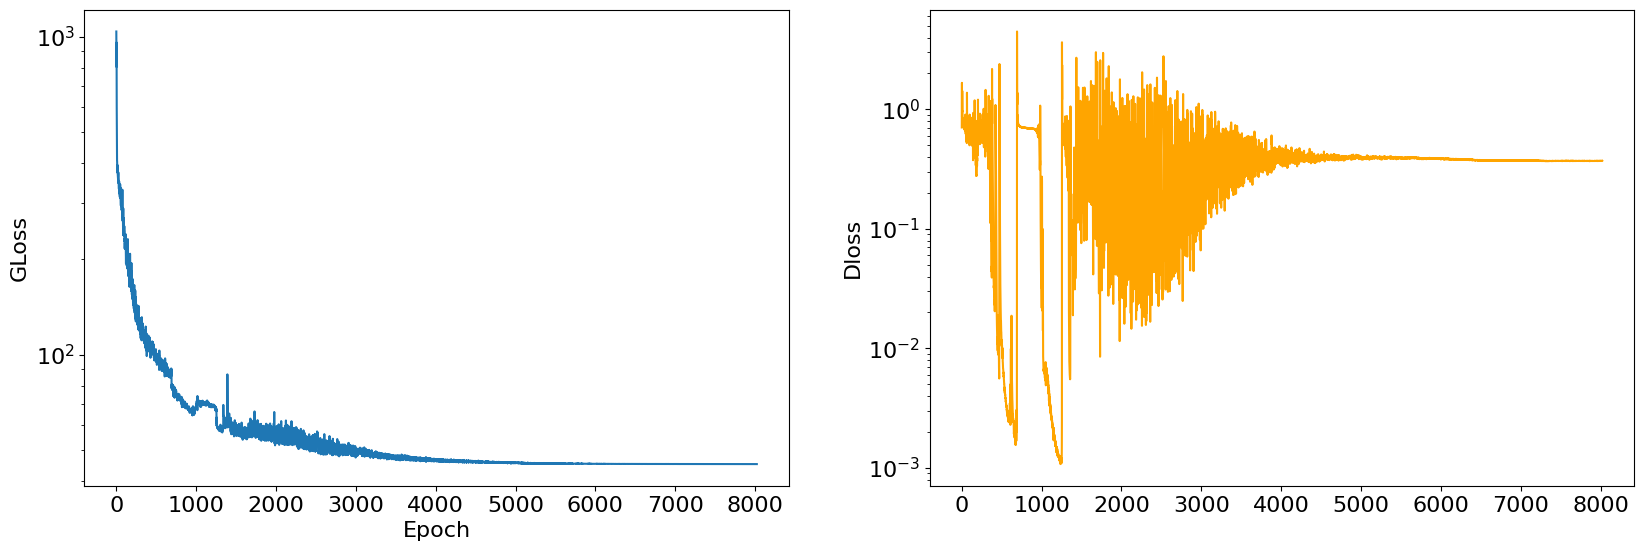

In [56]:
plt.rcParams['font.size'] = 16 
plt.figure(figsize=(20,6.18))
plt.subplot(121)
plt.plot(gan_model.Gloss_list)
plt.yscale('log')
plt.ylabel('GLoss')
plt.xlabel('Epoch')

plt.subplot(122)
plt.plot(gan_model.Dloss_list, 'orange')
plt.yscale('log')
plt.ylabel('Dloss')
plt.show()

In [ ]:
gan_model.netG.eval()
with torch.no_grad():
    nlfff_test, PF_test = gan_model.generate_latent(nums = 1, is_test = True)
    nlfff_test.detach()
    PF_test.detach()
    nlfff_pred = gan_model.netG(PF_test)
    nlfff_test_data = nlfff_test.detach().cpu().numpy()[0]
    nlfff_pred_data = nlfff_pred.detach().cpu().numpy()[0]

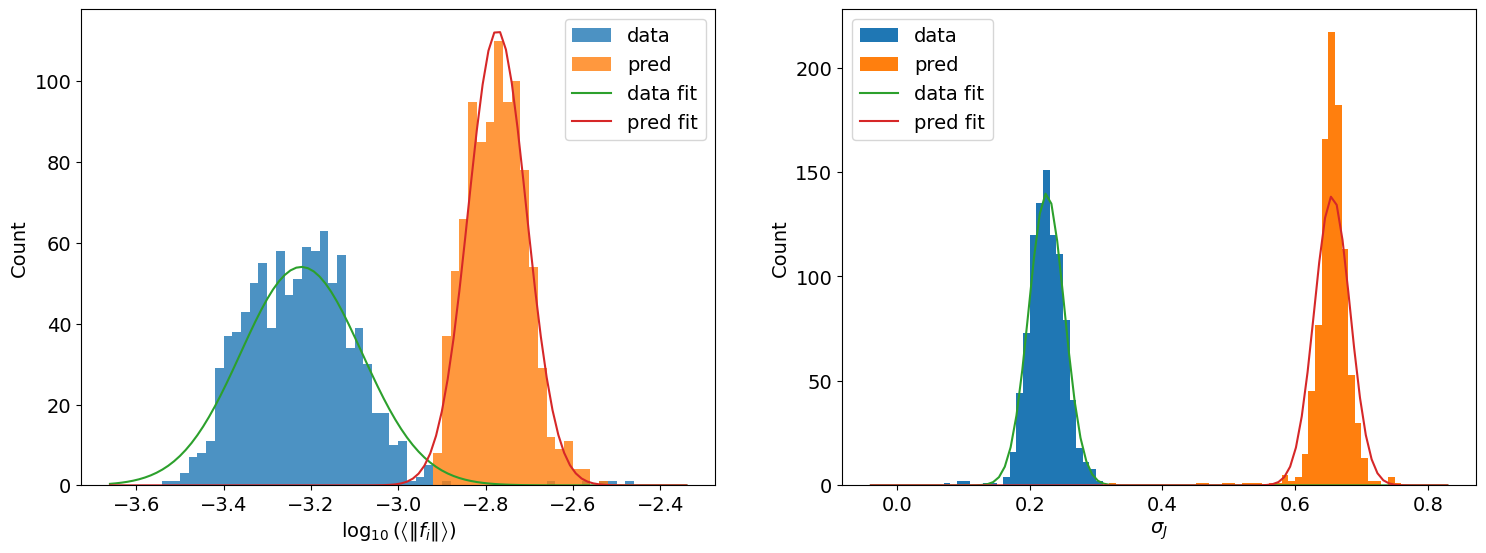

In [107]:
from scipy import stats

plt.rcParams['font.size'] = 14
plt.figure(figsize=(18,6.18))
plt.subplot(121)
bins = np.arange(-3.6,-2.4,0.02)
plt.hist(np.log10(eval_list[:,1]), bins=bins, alpha=0.8, label='data')
plt.hist(np.log10(eval_list[:,4]), bins=bins, alpha=0.8, label='pred')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
mu1, std1 = stats.norm.fit(np.log10(eval_list[:,1]))
mu2, std2 = stats.norm.fit(np.log10(eval_list[:,4]))
plt.plot(x,stats.norm.pdf(x, mu1, std1)*len(eval_list)*0.02,label='data fit')
plt.plot(x,stats.norm.pdf(x, mu2, std2)*len(eval_list)*0.02,label='pred fit')
plt.xlabel(r'$\log_{10}(\left<\|f_i\|\right>)$')
plt.ylabel('Count')
plt.legend()

plt.subplot(122)
bins = np.arange(0,0.8,0.01)
plt.hist(eval_list[:,2], bins=bins, label='data')
plt.hist(eval_list[:,5], bins=bins, label='pred')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
mu3, std3 = stats.norm.fit(eval_list[:,2])
mu4, std4 = stats.norm.fit(eval_list[:,5])
plt.plot(x,stats.norm.pdf(x, mu3, std3)*len(eval_list)*0.01,label='data fit')
plt.plot(x,stats.norm.pdf(x, mu4, std4)*len(eval_list)*0.01,label='pred fit')
plt.xlabel(r'$\sigma_{J}$')
plt.ylabel('Count')
plt.legend()

plt.savefig('Pred_vs_Data.png', bbox_inches='tight')
plt.show()

## Test in Training data

In [57]:
gan_model.file_name

'../nlfff/num_2900_2999/hmi.sharp_cea_720s.2923.20130702_080000_TAI/Bout.bin'

In [11]:
nlfff_file = gan_model.file_name
gan_model.netG.eval()
with torch.no_grad():
    nlfff_tensor, PF_tensor = gan_model.generate_latent(is_test=True, give_file=nlfff_file)
    nlfff_pred = gan_model.netG(PF_tensor)
    nlfff_data = nlfff_tensor.detach().cpu().numpy()[0]
    PF_data = PF_tensor.detach().cpu().numpy()[0]
    pred_data = nlfff_pred.detach().cpu().numpy()[0]

In [42]:
save_path = gan_model.save_pics_dir+'eval_on_training/'
os.makedirs(save_path, exist_ok=True)
for zi in range(nlfff_data.shape[3]):
    idir = 1
    plt.figure(figsize=(20,6.18*2))
    plt.subplot(221)
    plt.imshow(nlfff_data[idir,:,:,zi],origin='lower',cmap='gray')
    plt.title('NLFFF Data @ zi = %03d' % zi)
    plt.colorbar(fraction=0.028, pad=0.02)

    plt.subplot(222)
    plt.imshow(pred_data[idir,:,:,zi],origin='lower',cmap='gray')
    plt.title('Generated field @ zi = %03d' % zi)
    plt.colorbar(fraction=0.028, pad=0.02)

    b3_diff = np.abs(nlfff_data[idir,:,:,zi]-pred_data[idir,:,:,zi])/np.abs(nlfff_data).max()
    plt.subplot(223)
    plt.imshow(b3_diff*100,origin='lower',cmap='gray')
    plt.title('Relative difference (%)')
    plt.colorbar(fraction=0.028, pad=0.02)

    B = nlfff_data[:,:,:,zi:zi+1]
    b = nlfff_data[:,:,:,zi:zi+1]
    cos_theta = cube_dot(B,b)/np.sqrt(cube_dot(B,B))/np.sqrt(cube_dot(b,b))
    cos_theta = cos_theta[0,:,:,0]
    cos_theta = np.clip(cos_theta, -1, 1)
    theta = np.arccos(cos_theta) * 180. / np.pi
    plt.subplot(224)
    plt.imshow(theta,origin='lower',cmap='gray')
    plt.title(r'$\theta (\degree)$ between two field')
    plt.colorbar(fraction=0.028, pad=0.02)
    
    plt.savefig(save_path + 'eval_%03d.png' % zi, bbox_inches='tight')
    plt.close()


In [45]:
import cv2
import os

input_folder = save_path
output_video = save_path+'eval.mp4'

png_files = [f for f in os.listdir(input_folder) if f.endswith('.png')]
png_files.sort()  

first_image = cv2.imread(os.path.join(input_folder, png_files[0]))
height, width, layers = first_image.shape

fourcc = cv2.VideoWriter_fourcc(*'mp4v')  
video = cv2.VideoWriter(output_video, fourcc, 12, (width, height))

for png_file in png_files:
    image_path = os.path.join(input_folder, png_file)
    frame = cv2.imread(image_path)
    video.write(frame)

cv2.destroyAllWindows()
video.release()

In [ ]:
files_idx = np.random.choice(len(training_ds),1)[0]
files = training_ds[files_idx]
file_idx = np.random.choice(len(files),1)[0]
file_name = files[file_idx]
print(file_name)
nlfff_data = read_bcube(file_name)
PF_data = np.load(file_name[:-8:]+'PF_data.npy')
nlfff_data = adc_shape(nlfff_data)
PF_data = adc_shape(PF_data)

In [8]:
start_time = time.time()
gan_model.netG.eval()
with torch.no_grad():
    PF_tensor = torch.from_numpy(PF_data).unsqueeze(0).to(gan_model.device)
    nlfff_pred = gan_model.netG(PF_tensor)[0].detach().cpu().numpy()
print(nlfff_pred.shape)
end_time = time.time()
print('generate the NLFFF with time: %.2f [sec]' % (end_time-start_time))

(3, 144, 304, 176)
generate the NLFFF with time: 1.83 [sec]


In [59]:
fi_ref = div(nlfff_data)
fi_pre = div(nlfff_pred)
Ji_ref = rot(nlfff_data)
Ji_pre = rot(nlfff_pred)
th_ref = np.arcsin(np.clip(norm(cube_cross(Ji_ref,nlfff_data),axis=0)/norm(Ji_ref,axis=0)/norm(nlfff_data,axis=0),-1,1))*180/np.pi
th_pre = np.arcsin(np.clip(norm(cube_cross(Ji_pre,nlfff_pred),axis=0)/norm(Ji_pre,axis=0)/norm(nlfff_pred,axis=0),-1,1))*180/np.pi

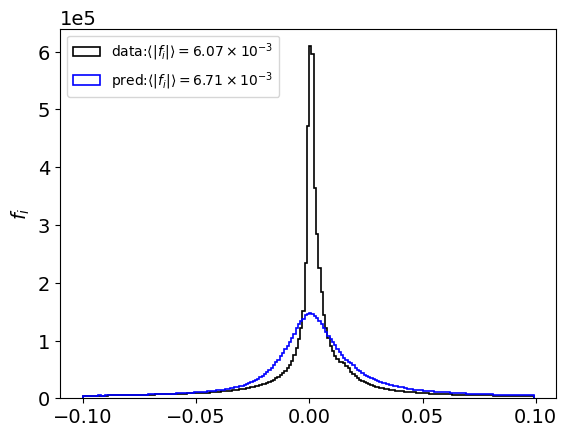

In [96]:
bins = np.arange(-0.1,0.1,0.001)
plt.hist(fi_ref.flatten(),bins=bins, histtype='step', color='black', linewidth=1.2,
         label=r'data:$\langle|f_i|\rangle=6.07\times 10^{-3}$')
plt.hist(fi_pre.flatten(),bins=bins, histtype='step', color='b', linewidth=1.2,
         label=r'pred:$\langle|f_i|\rangle=6.71\times 10^{-3}$')
plt.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))
plt.ylabel(r'$f_i$')
plt.legend(loc='upper left',fontsize=10)
plt.show()

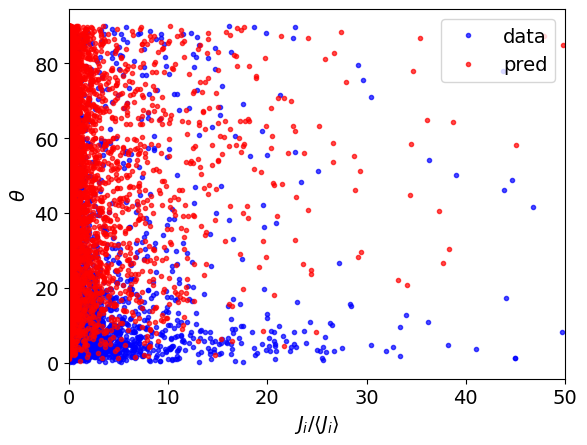

In [85]:
plt.rcParams['font.size'] = 14
idx = np.random.choice(len(th_ref.flatten()),10000,replace=False)
temp_x = (norm(Ji_ref,axis=0)/norm(Ji_ref,axis=0).mean()).flatten()[idx]
temp_y = th_ref.flatten()[idx]
plt.figure()
plt.plot(temp_x,temp_y,'.',c='b',ls='',alpha=0.7,label='data')
temp_x = (norm(Ji_pre,axis=0)/norm(Ji_pre,axis=0).mean()).flatten()[idx]
temp_y = th_pre.flatten()[idx]
plt.plot(temp_x,temp_y,'.',c='r',ls='',alpha=0.7,label='pred')
plt.xlim((0,50))
plt.xlabel(r'$J_i/\langle J_i\rangle$')
plt.ylabel(r'$\theta$')
plt.legend()
plt.show()